In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import cohen_kappa_score
from itertools import combinations

models = {
    'yandex': pd.read_csv('annotations_df_yandex.csv'),
    'gigachat': pd.read_csv('annotations_df_gigachat.csv'),
    'qwen': pd.read_csv('annotations_df_qwen.csv'),
    'mistral': pd.read_csv('annotations_df_mistral.csv'),
    'gpt-oss': pd.read_csv('annotations_df_gpt-oss.csv')
}

# Краткая статистика по каждой модели
stats = []
for name, df in models.items():
    stats.append({
        'model': name,
        'total_ann': len(df),
        'unique_images': df['image_id'].nunique(),
        'perceptual_%': (df['cognitive_type'] == 'perceptual').mean() * 100,
        'interpretive_%': (df['cognitive_type'] == 'interpretive').mean() * 100
    })
stats_df = pd.DataFrame(stats)
print(stats_df)

      model  total_ann  unique_images  perceptual_%  interpretive_%
0    yandex     194306            895     87.085834       12.818956
1  gigachat     194306            895     74.346134       25.653866
2      qwen     194306            895     79.087110       20.912890
3   mistral     194306            895     76.406802       23.546365
4   gpt-oss     193724            895     77.714687       22.285313



📊 РАСПРЕДЕЛЕНИЕ ПО ИСТОЧНИКУ (человек vs модель)

--- АБСОЛЮТНЫЕ ЗНАЧЕНИЯ ---
          perc_human  perc_model  interp_human  interp_model     total
yandex       86463.0     82750.0        2922.0       21986.0  194306.0
gigachat     77857.0     66602.0       11655.0       38192.0  194306.0
qwen         82907.0     70764.0        6605.0       34030.0  194306.0
mistral      81029.0     67434.0        8469.0       37283.0  194306.0
gpt-oss      81263.0     69289.0        7961.0       35211.0  193724.0

--- ПРОЦЕНТЫ (от всех аннотаций модели) ---
          perc_human_%  perc_model_%  interp_human_%  interp_model_%
yandex            44.5          42.6             1.5            11.3
gigachat          40.1          34.3             6.0            19.7
qwen              42.7          36.4             3.4            17.5
mistral           41.7          34.7             4.4            19.2
gpt-oss           41.9          35.8             4.1            18.2


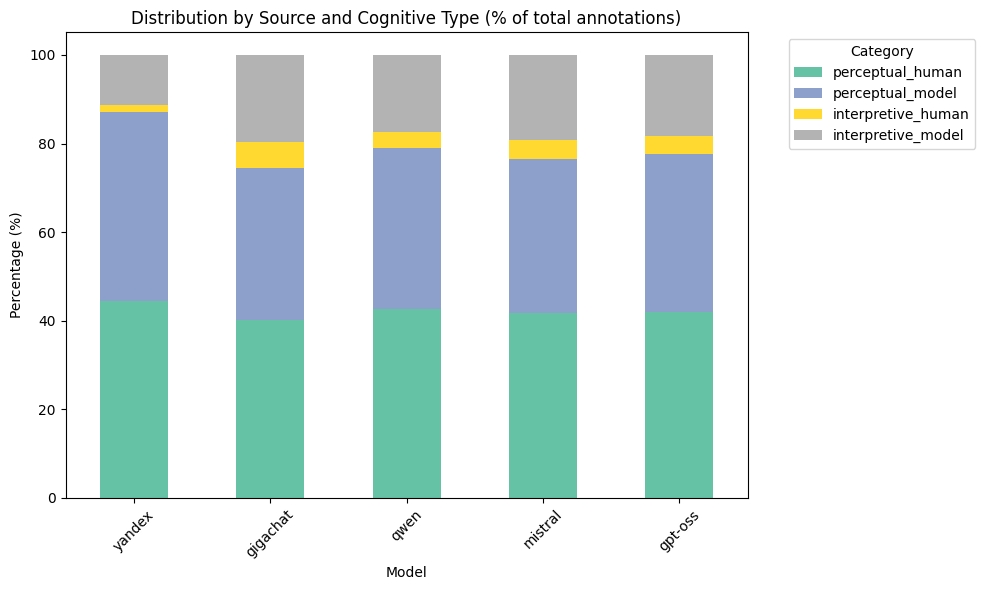

In [11]:
# Анализ по source (человек/модель) в процентах
source_stats = {}
for name, df in models.items():
    total = len(df)

    # Абсолютные значения
    perc_human = df[(df['cognitive_type'] == 'perceptual') & (df['source'] == 'человек')].shape[0]
    perc_model = df[(df['cognitive_type'] == 'perceptual') & (df['source'] == 'модель')].shape[0]
    interp_human = df[(df['cognitive_type'] == 'interpretive') & (df['source'] == 'человек')].shape[0]
    interp_model = df[(df['cognitive_type'] == 'interpretive') & (df['source'] == 'модель')].shape[0]

    # Проценты от общего количества аннотаций модели
    source_stats[name] = {
        'perc_human': perc_human,
        'perc_model': perc_model,
        'interp_human': interp_human,
        'interp_model': interp_model,
        'perc_human_%': (perc_human / total * 100) if total > 0 else 0,
        'perc_model_%': (perc_model / total * 100) if total > 0 else 0,
        'interp_human_%': (interp_human / total * 100) if total > 0 else 0,
        'interp_model_%': (interp_model / total * 100) if total > 0 else 0,
        'total': total
    }

source_df = pd.DataFrame(source_stats).T
source_df = source_df.round(1)

print("\n" + "="*80)
print("📊 РАСПРЕДЕЛЕНИЕ ПО ИСТОЧНИКУ (человек vs модель)")
print("="*80)
print("\n--- АБСОЛЮТНЫЕ ЗНАЧЕНИЯ ---")
print(source_df[['perc_human', 'perc_model', 'interp_human', 'interp_model', 'total']].to_string())

print("\n--- ПРОЦЕНТЫ (от всех аннотаций модели) ---")
print(source_df[['perc_human_%', 'perc_model_%', 'interp_human_%', 'interp_model_%']].to_string())

# Визуализация в процентах (stacked bar chart)
fig, ax = plt.subplots(figsize=(10, 6))

# Подготовка данных для stacked bar
categories = ['perceptual_human', 'perceptual_model', 'interpretive_human', 'interpretive_model']
plot_data = source_df[['perc_human_%', 'perc_model_%', 'interp_human_%', 'interp_model_%']].copy()
plot_data.columns = categories

plot_data.plot(kind='bar', stacked=True, ax=ax, colormap='Set2')
ax.set_xlabel('Model')
ax.set_ylabel('Percentage (%)')
ax.set_title('Distribution by Source and Cognitive Type (% of total annotations)')
ax.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('source_distribution.pdf')
plt.show()

In [12]:
# Список perceptual subtypes (из ваших данных)
PERCEPTUAL_SUBTYPES = [
    "person type", "person property", "clothing item", "color",
    "nature and landscape", "architecture", "spatial", "animal",
    "action", "item", "object property"
]

# Список interpretive subtypes
INTERPRETIVE_SUBTYPES = [
    "emotion", "mood", "social role", "time", "religion",
    "artistic property", "activity", "clothing property",
    "aesthetic evaluation", "status marker"
]

# Расчет процентов для каждой модели
results = []

for name, df in models.items():
    total_perceptual = df[df['cognitive_type'] == 'perceptual'].shape[0]
    total_interpretive = df[df['cognitive_type'] == 'interpretive'].shape[0]

    # Проценты perceptual subtypes
    perc_stats = {}
    for st in PERCEPTUAL_SUBTYPES:
        count = df[(df['cognitive_type'] == 'perceptual') & (df['subtype'] == st)].shape[0]
        perc_stats[f'perc_{st}'] = (count / total_perceptual * 100) if total_perceptual > 0 else 0

    # Проценты interpretive subtypes
    interp_stats = {}
    for st in INTERPRETIVE_SUBTYPES:
        count = df[(df['cognitive_type'] == 'interpretive') & (df['subtype'] == st)].shape[0]
        interp_stats[f'interp_{st}'] = (count / total_interpretive * 100) if total_interpretive > 0 else 0

    results.append({'model': name, **perc_stats, **interp_stats})

results_df = pd.DataFrame(results)
results_df = results_df.round(1)

print("\n" + "="*70)
print("📊 PERCEPTUAL SUBTYPES (% от всех perceptual аннотаций модели)")
print("="*70)
perc_cols = [c for c in results_df.columns if c.startswith('perc_')]
print(results_df[['model'] + perc_cols].to_string(index=False))

print("\n" + "="*70)
print("📊 INTERPRETIVE SUBTYPES (% от всех interpretive аннотаций модели)")
print("="*70)
interp_cols = [c for c in results_df.columns if c.startswith('interp_')]
print(results_df[['model'] + interp_cols].to_string(index=False))


📊 PERCEPTUAL SUBTYPES (% от всех perceptual аннотаций модели)
   model  perc_person type  perc_person property  perc_clothing item  perc_color  perc_nature and landscape  perc_architecture  perc_spatial  perc_animal  perc_action  perc_item  perc_object property
  yandex               6.3                   7.4                 9.4        21.4                        8.9                3.3           4.7          2.4         11.3       15.5                   7.3
gigachat               6.4                   8.8                15.1        14.4                        7.5                4.0          10.0          2.6          7.1        1.0                   9.2
    qwen               7.4                   9.1                 7.1        24.2                        8.5                3.2           5.0          2.2          8.0       10.9                  13.1
 mistral               7.3                  14.7                 8.5        20.9                       10.1                5.2           

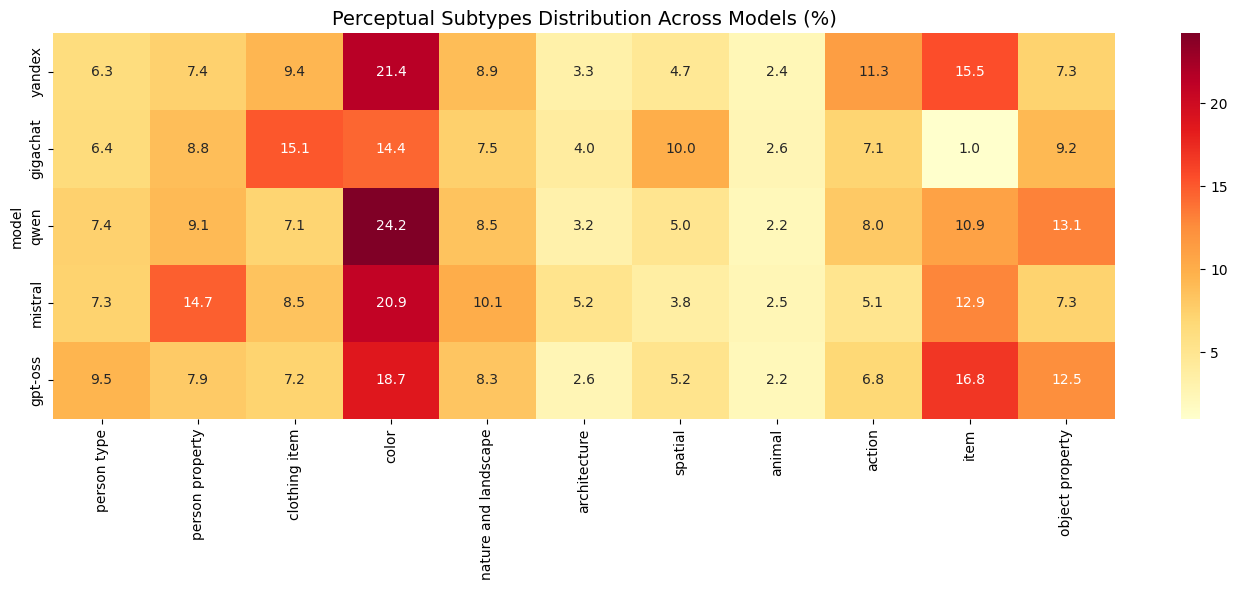

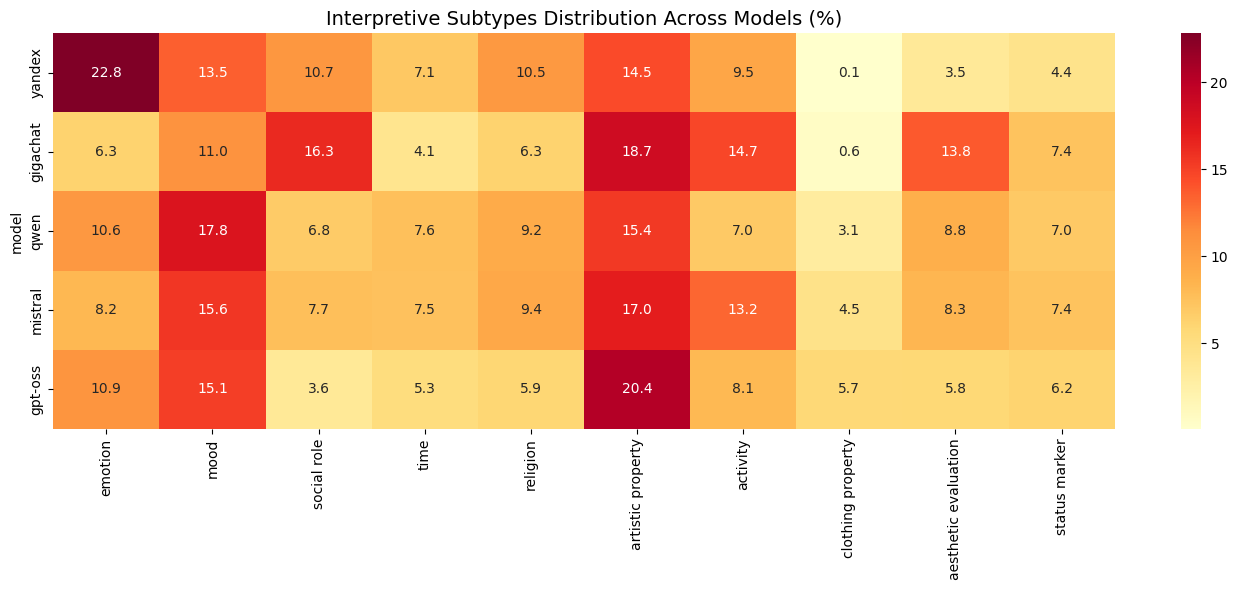

In [13]:
# Тепловая карта для perceptual subtypes
fig, ax = plt.subplots(figsize=(14, 6))
heatmap_data = results_df.set_index('model')[perc_cols]
heatmap_data.columns = [c.replace('perc_', '') for c in heatmap_data.columns]
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax)
ax.set_title('Perceptual Subtypes Distribution Across Models (%)', fontsize=14)
plt.tight_layout()
plt.savefig('perceptual_heatmap.pdf')
plt.show()

# Тепловая карта для interpretive subtypes
fig, ax = plt.subplots(figsize=(14, 6))
heatmap_data = results_df.set_index('model')[interp_cols]
heatmap_data.columns = [c.replace('interp_', '') for c in heatmap_data.columns]
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax)
ax.set_title('Interpretive Subtypes Distribution Across Models (%)', fontsize=14)
plt.tight_layout()
plt.savefig('interpretive_heatmap.pdf')
plt.show()

In [14]:
# Сохраняем в Excel
with pd.ExcelWriter('models_subtypes_comparison.xlsx') as writer:
    results_df.to_excel(writer, sheet_name='All_Subtypes', index=False)

    # Только perceptual
    results_df[['model'] + perc_cols].to_excel(writer, sheet_name='Perceptual', index=False)

    # Только interpretive
    results_df[['model'] + interp_cols].to_excel(writer, sheet_name='Interpretive', index=False)

print("\n✅ Результаты сохранены в models_subtypes_comparison.xlsx")


✅ Результаты сохранены в models_subtypes_comparison.xlsx


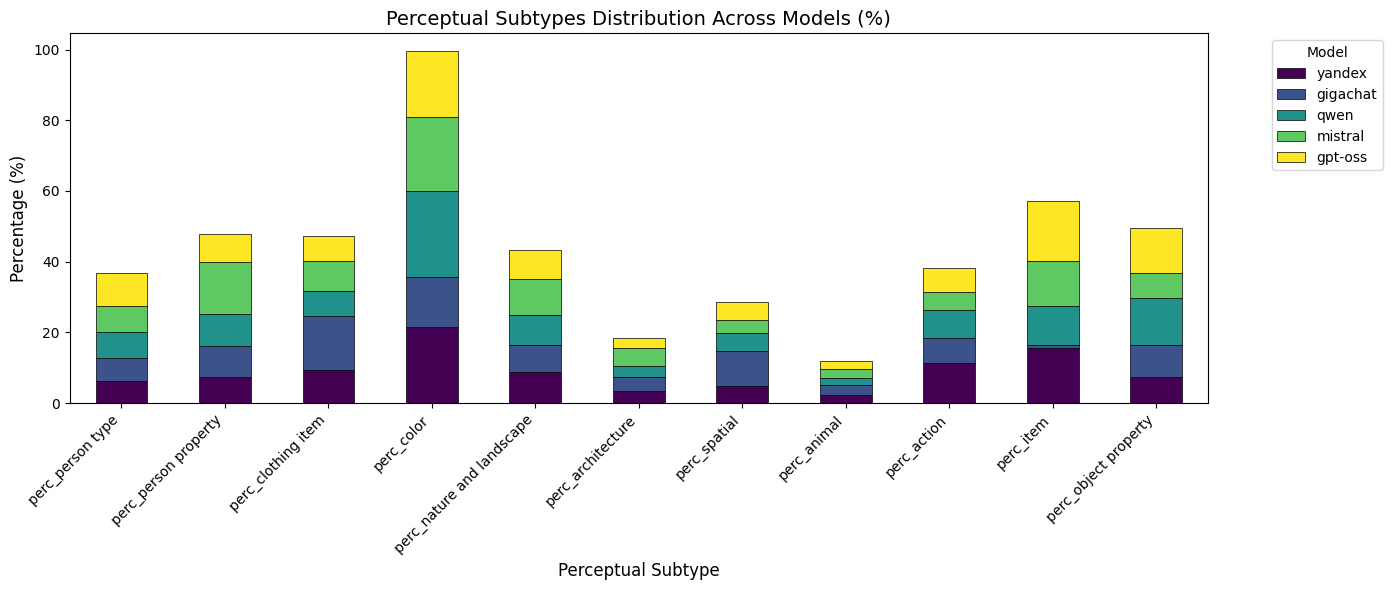

In [15]:
# Perceptual subtypes - stacked bar chart
fig, ax = plt.subplots(figsize=(14, 6))
plot_data = results_df.set_index('model')[perc_cols].T
plot_data.columns = [c.replace('perc_', '') for c in plot_data.columns]

plot_data.plot(kind='bar', stacked=True, ax=ax, colormap='viridis', edgecolor='black', linewidth=0.5)
ax.set_xlabel('Perceptual Subtype', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Perceptual Subtypes Distribution Across Models (%)', fontsize=14)
ax.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig('perceptual_stacked_bar.pdf')
plt.show()

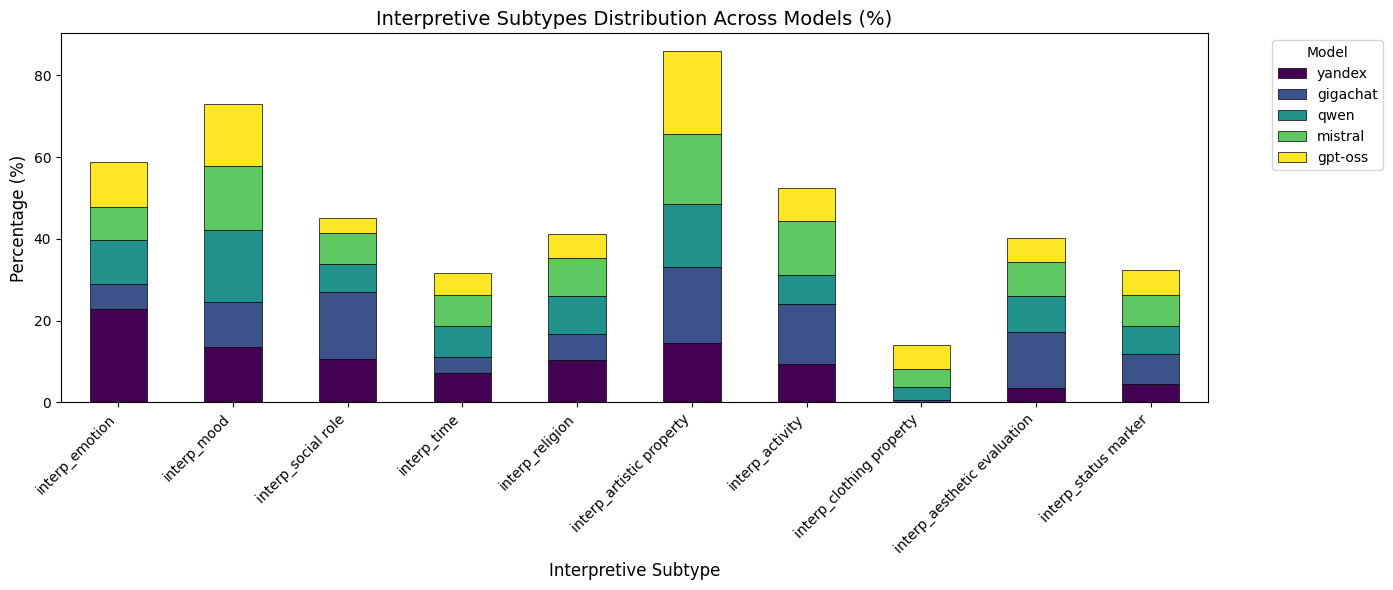

In [16]:
# Interpretive subtypes - stacked bar chart
fig, ax = plt.subplots(figsize=(14, 6))
plot_data = results_df.set_index('model')[interp_cols].T
plot_data.columns = [c.replace('interp_', '') for c in plot_data.columns]

plot_data.plot(kind='bar', stacked=True, ax=ax, colormap='viridis', edgecolor='black', linewidth=0.5)
ax.set_xlabel('Interpretive Subtype', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Interpretive Subtypes Distribution Across Models (%)', fontsize=14)
ax.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig('interpretive_stacked_bar.pdf')
plt.show()

## Дополнительные идеи для анализа

1. **Fleiss' kappa** – мера согласованности между всеми 5 моделями (для номинативных данных cognitive_type).
2. **Анализ расхождений** – найти изображения, где модели сильно расходятся (например, одна модель дала `interpretive`, остальные `perceptual`). Это может указывать на спорные случаи.
3. **Корреляция subtypes** – посчитать, насколько часто конкретные subtypes встречаются вместе (например, если модель отметила `emotion`, то с какой вероятностью отметит `mood`).
4. **Сравнение с золотым стандартом** (если есть человеческая разметка). Рассчитать precision/recall для каждой модели.
5. **Длина контекста** – влияет ли длина текста (`context`) на выбор cognitive_type? (средняя длина контекста для perceptual vs interpretive).
6. **Анализ по конкретным изображениям** – выбрать топ-5 изображений с максимальным разбросом и визуализировать аннотации.
7. **Кластеризация моделей** – на основе распределения subtypes (можно использовать t-SNE или иерархическую кластеризацию).

In [17]:
# 1. Проверка пересечения image_id между моделями
print("="*60)
print("📊 ПРОВЕРКА ПЕРЕСЕЧЕНИЙ IMAGE_ID")
print("="*60)

for name, df in models.items():
    print(f"{name}: {df['image_id'].nunique()} уникальных image_id")

# Попарное пересечение
for name1, name2 in combinations(models.keys(), 2):
    set1 = set(models[name1]['image_id'])
    set2 = set(models[name2]['image_id'])
    overlap = len(set1 & set2)
    print(f"{name1} vs {name2}: {overlap} общих ({overlap/895*100:.1f}%)")

📊 ПРОВЕРКА ПЕРЕСЕЧЕНИЙ IMAGE_ID
yandex: 895 уникальных image_id
gigachat: 895 уникальных image_id
qwen: 895 уникальных image_id
mistral: 895 уникальных image_id
gpt-oss: 895 уникальных image_id
yandex vs gigachat: 895 общих (100.0%)
yandex vs qwen: 895 общих (100.0%)
yandex vs mistral: 895 общих (100.0%)
yandex vs gpt-oss: 895 общих (100.0%)
gigachat vs qwen: 895 общих (100.0%)
gigachat vs mistral: 895 общих (100.0%)
gigachat vs gpt-oss: 895 общих (100.0%)
qwen vs mistral: 895 общих (100.0%)
qwen vs gpt-oss: 895 общих (100.0%)
mistral vs gpt-oss: 895 общих (100.0%)


In [19]:
# 2. Проверка распределения cognitive_type по моделям
print("\n" + "="*60)
print("📊 РАСПРЕДЕЛЕНИЕ COGNITIVE_TYPE")
print("="*60)

for name, df in models.items():
    dist = df['cognitive_type'].value_counts(normalize=True) * 100
    print(f"\n{name}:")
    print(dist.round(1))


📊 РАСПРЕДЕЛЕНИЕ COGNITIVE_TYPE

yandex:
cognitive_type
perceptual      87.1
interpretive    12.8
spatial          0.1
action           0.0
perceptive       0.0
none             0.0
Name: proportion, dtype: float64

gigachat:
cognitive_type
perceptual      74.3
interpretive    25.7
Name: proportion, dtype: float64

qwen:
cognitive_type
perceptual      79.1
interpretive    20.9
Name: proportion, dtype: float64

mistral:
cognitive_type
perceptual      76.4
interpretive    23.5
unknown          0.0
item             0.0
none             0.0
perceptial       0.0
Name: proportion, dtype: float64

gpt-oss:
cognitive_type
perceptual      77.7
interpretive    22.3
Name: proportion, dtype: float64


In [20]:
# 3. Проверка согласия на ПЕРВЫХ 10 image_id (для отладки)
print("\n" + "="*60)
print("📊 ПРИМЕР СОГЛАСИЯ ДЛЯ ПЕРВЫХ 10 IMAGE_ID")
print("="*60)

# Берем первые 10 image_id из yandex
sample_ids = list(models['yandex']['image_id'].unique())[:10]

for img_id in sample_ids:
    row = {'image_id': img_id}
    for name, df in models.items():
        cog = df[df['image_id'] == img_id]['cognitive_type'].values
        row[name] = cog[0] if len(cog) > 0 else 'NO_DATA'
    print(row)


📊 ПРИМЕР СОГЛАСИЯ ДЛЯ ПЕРВЫХ 10 IMAGE_ID
{'image_id': 'id_706', 'yandex': 'perceptual', 'gigachat': 'interpretive', 'qwen': 'perceptual', 'mistral': 'interpretive', 'gpt-oss': 'perceptual'}
{'image_id': 'id_442', 'yandex': 'perceptual', 'gigachat': 'perceptual', 'qwen': 'perceptual', 'mistral': 'perceptual', 'gpt-oss': 'perceptual'}
{'image_id': 'id_451', 'yandex': 'perceptual', 'gigachat': 'perceptual', 'qwen': 'perceptual', 'mistral': 'perceptual', 'gpt-oss': 'perceptual'}
{'image_id': 'id_728', 'yandex': 'perceptual', 'gigachat': 'perceptual', 'qwen': 'perceptual', 'mistral': 'perceptual', 'gpt-oss': 'perceptual'}
{'image_id': 'id_387', 'yandex': 'perceptual', 'gigachat': 'perceptual', 'qwen': 'interpretive', 'mistral': 'perceptual', 'gpt-oss': 'perceptual'}
{'image_id': 'id_494', 'yandex': 'interpretive', 'gigachat': 'interpretive', 'qwen': 'interpretive', 'mistral': 'perceptual', 'gpt-oss': 'perceptual'}
{'image_id': 'id_695', 'yandex': 'perceptual', 'gigachat': 'interpretive', '

In [27]:
# 4. Правильный расчет согласия (только на общих image_id)
print("\n" + "="*60)
print("📊 ПРАВИЛЬНЫЙ AGREEMENT(ТОЛЬКО НА ОБЩИХ IMAGE_ID)")
print("="*60)

# Общие image_id для ВСЕХ моделей
common_ids = None
for name, df in models.items():
    ids = set(df['image_id'].unique())
    if common_ids is None:
        common_ids = ids
    else:
        common_ids = common_ids & ids

print(f"Общих image_id для ВСЕХ моделей: {len(common_ids)}")

# Строим единую таблицу
agreement_matrix = pd.DataFrame(index=models.keys(), columns=models.keys(), dtype=float)

for name1, name2 in combinations(models.keys(), 2):
    # Создаем словари {image_id: cognitive_type}
    dict1 = dict(zip(models[name1]['image_id'], models[name1]['cognitive_type']))
    dict2 = dict(zip(models[name2]['image_id'], models[name2]['cognitive_type']))

    matches = 0
    total = 0

    for img_id in common_ids:
        if dict1.get(img_id) == dict2.get(img_id):
            matches += 1
        total += 1

    agreement = matches / total
    agreement_matrix.loc[name1, name2] = agreement
    agreement_matrix.loc[name2, name1] = agreement
    print(f"{name1} vs {name2}: {agreement:.2%} ({matches}/{total})")

for name in models.keys():
    agreement_matrix.loc[name, name] = 1.0

print("\nМАТРИЦА СОГЛАСИЯ (доля совпадений):")
print(agreement_matrix.round(3))


📊 ПРАВИЛЬНЫЙ AGREEMENT(ТОЛЬКО НА ОБЩИХ IMAGE_ID)
Общих image_id для ВСЕХ моделей: 895
yandex vs gigachat: 83.35% (746/895)
yandex vs qwen: 89.61% (802/895)
yandex vs mistral: 63.13% (565/895)
yandex vs gpt-oss: 72.29% (647/895)
gigachat vs qwen: 86.82% (777/895)
gigachat vs mistral: 60.00% (537/895)
gigachat vs gpt-oss: 63.13% (565/895)
qwen vs mistral: 60.00% (537/895)
qwen vs gpt-oss: 65.81% (589/895)
mistral vs gpt-oss: 64.92% (581/895)

МАТРИЦА СОГЛАСИЯ (доля совпадений):
          yandex  gigachat   qwen  mistral  gpt-oss
yandex     1.000     0.834  0.896    0.631    0.723
gigachat   0.834     1.000  0.868    0.600    0.631
qwen       0.896     0.868  1.000    0.600    0.658
mistral    0.631     0.600  0.600    1.000    0.649
gpt-oss    0.723     0.631  0.658    0.649    1.000


In [23]:
from sklearn.metrics import cohen_kappa_score

print("\n" + "="*60)
print("📊 COHEN'S KAPPA (С УЧЕТОМ СЛУЧАЙНОГО СОГЛАСИЯ)")
print("="*60)

# Общие image_id для всех моделей
common_ids = None
for name, df in models.items():
    ids = set(df['image_id'].unique())
    if common_ids is None:
        common_ids = ids
    else:
        common_ids = common_ids & ids

common_ids = sorted(list(common_ids))

# Создаем словари для быстрого доступа
dicts = {}
for name, df in models.items():
    dicts[name] = dict(zip(df['image_id'], df['cognitive_type']))

cohen_matrix = pd.DataFrame(index=models.keys(), columns=models.keys(), dtype=float)

for name1, name2 in combinations(models.keys(), 2):
    # Создаем списки в одинаковом порядке
    list1 = [dicts[name1][img_id] for img_id in common_ids]
    list2 = [dicts[name2][img_id] for img_id in common_ids]

    kappa = cohen_kappa_score(list1, list2)
    cohen_matrix.loc[name1, name2] = kappa
    cohen_matrix.loc[name2, name1] = kappa
    print(f"{name1} vs {name2}: {kappa:.4f}")

for name in models.keys():
    cohen_matrix.loc[name, name] = 1.0

print("\nМАТРИЦА COHEN'S KAPPA:")
print(cohen_matrix.round(4))

# Статистика
values = cohen_matrix.values[np.triu_indices_from(cohen_matrix.values, k=1)]
print(f"\n{'='*60}")
print(f"Средний Cohen's Kappa: {values.mean():.4f}")
print(f"Медиана: {np.median(values):.4f}")
print(f"Мин: {values.min():.4f} ({cohen_matrix.stack().idxmin()})")
print(f"Макс: {values.max():.4f} ({cohen_matrix.stack().idxmax()})")

# Интерпретация
print(f"\n{'='*60}")
print("ИНТЕРПРЕТАЦИЯ:")
print("-"*60)
if values.mean() < 0:
    print("Слабее случайного (Poor)")
elif values.mean() < 0.20:
    print("Незначительное согласие (Slight)")
elif values.mean() < 0.40:
    print("Умеренное согласие (Fair)")
elif values.mean() < 0.60:
    print("Среднее согласие (Moderate)")
elif values.mean() < 0.80:
    print("Существенное согласие (Substantial)")
else:
    print("Почти полное согласие (Almost perfect)")


📊 COHEN'S KAPPA (С УЧЕТОМ СЛУЧАЙНОГО СОГЛАСИЯ)
yandex vs gigachat: 0.6193
yandex vs qwen: 0.7524
yandex vs mistral: 0.1215
yandex vs gpt-oss: 0.0385
gigachat vs qwen: 0.7114
gigachat vs mistral: 0.1244
gigachat vs gpt-oss: 0.0472
qwen vs mistral: 0.1010
qwen vs gpt-oss: 0.0395
mistral vs gpt-oss: 0.0144

МАТРИЦА COHEN'S KAPPA:
          yandex  gigachat    qwen  mistral  gpt-oss
yandex    1.0000    0.6193  0.7524   0.1215   0.0385
gigachat  0.6193    1.0000  0.7114   0.1244   0.0472
qwen      0.7524    0.7114  1.0000   0.1010   0.0395
mistral   0.1215    0.1244  0.1010   1.0000   0.0144
gpt-oss   0.0385    0.0472  0.0395   0.0144   1.0000

Средний Cohen's Kappa: 0.2570
Медиана: 0.1113
Мин: 0.0144 (('mistral', 'gpt-oss'))
Макс: 0.7524 (('yandex', 'yandex'))

ИНТЕРПРЕТАЦИЯ:
------------------------------------------------------------
Умеренное согласие (Fair)


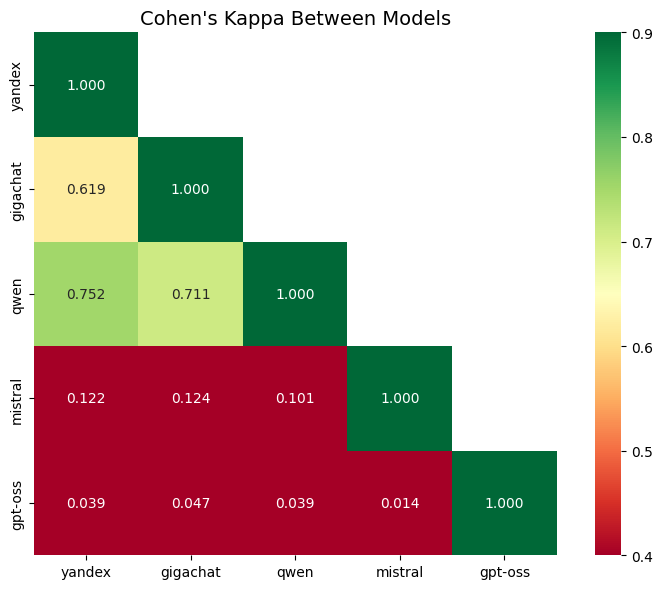

In [24]:
# Визуализация Cohen's Kappa
fig, ax = plt.subplots(figsize=(8, 6))

# Маска для верхней половины
mask = np.triu(np.ones_like(cohen_matrix, dtype=bool), k=1)

sns.heatmap(cohen_matrix, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0.4, vmax=0.9, square=True, ax=ax, mask=mask)
ax.set_title("Cohen's Kappa Between Models", fontsize=14)
plt.tight_layout()
plt.savefig('cohen_kappa.pdf')
plt.show()

In [25]:
# Проверка распределения cognitive_type по моделям
print("="*60)
print("📊 РАСПРЕДЕЛЕНИЕ COGNITIVE_TYPE (В ПРОЦЕНТАХ)")
print("="*60)

for name, df in models.items():
    dist = df['cognitive_type'].value_counts(normalize=True) * 100
    print(f"\n{name}:")
    for cog_type, pct in dist.items():
        print(f"  {cog_type}: {pct:.1f}%")

📊 РАСПРЕДЕЛЕНИЕ COGNITIVE_TYPE (В ПРОЦЕНТАХ)

yandex:
  perceptual: 87.1%
  interpretive: 12.8%
  spatial: 0.1%
  action: 0.0%
  perceptive: 0.0%
  none: 0.0%

gigachat:
  perceptual: 74.3%
  interpretive: 25.7%

qwen:
  perceptual: 79.1%
  interpretive: 20.9%

mistral:
  perceptual: 76.4%
  interpretive: 23.5%
  unknown: 0.0%
  item: 0.0%
  none: 0.0%
  perceptial: 0.0%

gpt-oss:
  perceptual: 77.7%
  interpretive: 22.3%


In [26]:
# Используем agreement matrix (уже есть)
print("\nМАТРИЦА СОГЛАСИЯ (доля совпадений):")
print(agreement_matrix.round(3))


МАТРИЦА СОГЛАСИЯ (доля совпадений):
          yandex  gigachat   qwen  mistral  gpt-oss
yandex     1.000     0.834  0.896    0.631    0.723
gigachat   0.834     1.000  0.868    0.600    0.631
qwen       0.896     0.868  1.000    0.600    0.658
mistral    0.631     0.600  0.600    1.000    0.649
gpt-oss    0.723     0.631  0.658    0.649    1.000


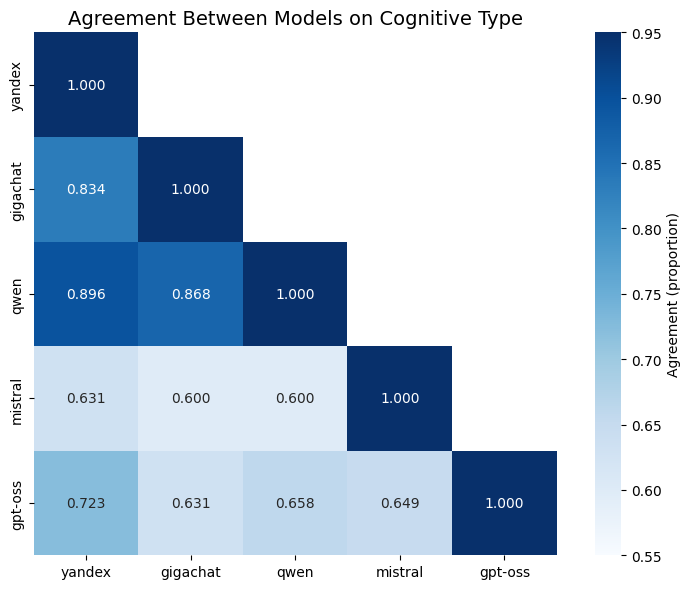

In [28]:
# Матрица согласия (Agreement) - визуализация
fig, ax = plt.subplots(figsize=(8, 6))

# Маска для верхней половины (чтобы не дублировать)
mask = np.triu(np.ones_like(agreement_matrix, dtype=bool), k=1)

# Тепловая карта agreement
sns.heatmap(agreement_matrix, annot=True, fmt='.3f', cmap='Blues',
            vmin=0.55, vmax=0.95, square=True, ax=ax, mask=mask,
            cbar_kws={'label': 'Agreement (proportion)'})
ax.set_title("Agreement Between Models on Cognitive Type", fontsize=14)

plt.tight_layout()
plt.savefig('agreement_matrix.pdf')
plt.show()

📊 COHEN'S KAPPA ДЛЯ COGNITIVE TYPE
Общих image_id для всех моделей: 895
yandex vs gigachat: 0.6193
yandex vs qwen: 0.7524
yandex vs mistral: 0.1215
yandex vs gpt-oss: 0.0385
gigachat vs qwen: 0.7114
gigachat vs mistral: 0.1244
gigachat vs gpt-oss: 0.0472
qwen vs mistral: 0.1010
qwen vs gpt-oss: 0.0395
mistral vs gpt-oss: 0.0144

МАТРИЦА COHEN'S KAPPA:
          yandex  gigachat    qwen  mistral  gpt-oss
yandex    1.0000    0.6193  0.7524   0.1215   0.0385
gigachat  0.6193    1.0000  0.7114   0.1244   0.0472
qwen      0.7524    0.7114  1.0000   0.1010   0.0395
mistral   0.1215    0.1244  0.1010   1.0000   0.0144
gpt-oss   0.0385    0.0472  0.0395   0.0144   1.0000

Средний Cohen's Kappa: 0.2570
Медиана: 0.1113
Мин: 0.0144
Макс: 0.7524

ИНТЕРПРЕТАЦИЯ:
Умеренное согласие (Fair)


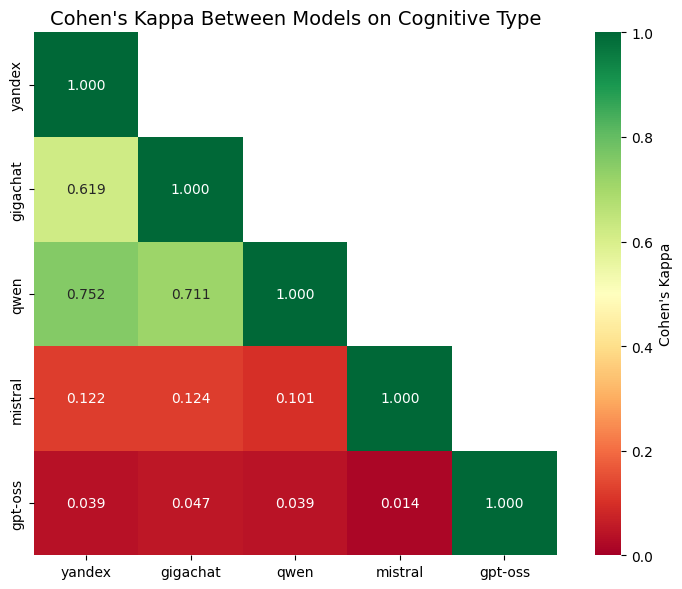

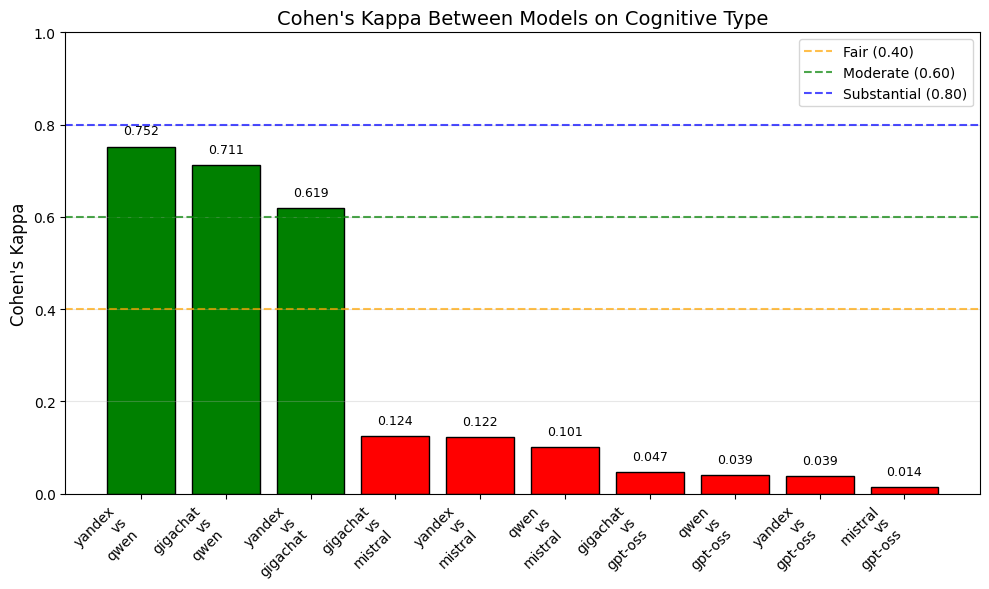

In [30]:
from sklearn.metrics import cohen_kappa_score
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations

print("="*60)
print("📊 COHEN'S KAPPA ДЛЯ COGNITIVE TYPE")
print("="*60)

# Находим общие image_id для всех моделей
common_ids = None
for name, df in models.items():
    ids = set(df['image_id'].unique())
    if common_ids is None:
        common_ids = ids
    else:
        common_ids = common_ids & ids

common_ids = sorted(list(common_ids))
print(f"Общих image_id для всех моделей: {len(common_ids)}")

# Создаем словари для быстрого доступа
dicts = {}
for name, df in models.items():
    dicts[name] = dict(zip(df['image_id'], df['cognitive_type']))

# Расчет Cohen's Kappa для каждой пары
kappa_matrix = pd.DataFrame(index=models.keys(), columns=models.keys(), dtype=float)

for name1, name2 in combinations(models.keys(), 2):
    # Создаем списки в одинаковом порядке
    list1 = [dicts[name1][img_id] for img_id in common_ids]
    list2 = [dicts[name2][img_id] for img_id in common_ids]

    kappa = cohen_kappa_score(list1, list2)
    kappa_matrix.loc[name1, name2] = kappa
    kappa_matrix.loc[name2, name1] = kappa
    print(f"{name1} vs {name2}: {kappa:.4f}")

# Заполняем диагональ
for name in models.keys():
    kappa_matrix.loc[name, name] = 1.0

print("\nМАТРИЦА COHEN'S KAPPA:")
print(kappa_matrix.round(4))

# Статистика
values = kappa_matrix.values[np.triu_indices_from(kappa_matrix.values, k=1)]
print(f"\n{'='*60}")
print(f"Средний Cohen's Kappa: {values.mean():.4f}")
print(f"Медиана: {np.median(values):.4f}")
print(f"Мин: {values.min():.4f}")
print(f"Макс: {values.max():.4f}")

# Интерпретация
print(f"\n{'='*60}")
print("ИНТЕРПРЕТАЦИЯ:")
if values.mean() < 0:
    print("Слабее случайного (Poor)")
elif values.mean() < 0.20:
    print("Незначительное согласие (Slight)")
elif values.mean() < 0.40:
    print("Умеренное согласие (Fair)")
elif values.mean() < 0.60:
    print("Среднее согласие (Moderate)")
elif values.mean() < 0.80:
    print("Существенное согласие (Substantial)")
else:
    print("Почти полное согласие (Almost perfect)")

# ============================================================
# ТЕПЛОВАЯ КАРТА COHEN'S KAPPA
# ============================================================
fig, ax = plt.subplots(figsize=(8, 6))

# Маска для верхней половины (чтобы не дублировать)
mask = np.triu(np.ones_like(kappa_matrix, dtype=bool), k=1)

# Тепловая карта
sns.heatmap(kappa_matrix, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0, vmax=1, square=True, ax=ax, mask=mask,
            cbar_kws={'label': "Cohen's Kappa"})
ax.set_title("Cohen's Kappa Between Models on Cognitive Type", fontsize=14)

plt.tight_layout()
plt.savefig('cohen_kappa_heatmap.pdf')
plt.show()

# Альтернатива: clustered bar chart (если не любите тепловые карты)
fig, ax = plt.subplots(figsize=(10, 6))

# Преобразуем матрицу в длинный формат
kappa_long = kappa_matrix.where(np.triu(np.ones_like(kappa_matrix, dtype=bool), k=1)).stack()
kappa_long = kappa_long.reset_index()
kappa_long.columns = ['Model 1', 'Model 2', 'Kappa']
kappa_long = kappa_long.sort_values('Kappa', ascending=False)

# Bar chart
colors = ['green' if x >= 0.6 else 'orange' if x >= 0.4 else 'red' for x in kappa_long['Kappa']]
bars = ax.bar(range(len(kappa_long)), kappa_long['Kappa'], color=colors, edgecolor='black')

ax.set_xticks(range(len(kappa_long)))
ax.set_xticklabels([f"{row['Model 1']}\nvs\n{row['Model 2']}" for _, row in kappa_long.iterrows()],
                   rotation=45, ha='right', fontsize=10)
ax.set_ylabel("Cohen's Kappa", fontsize=12)
ax.set_title("Cohen's Kappa Between Models on Cognitive Type", fontsize=14)
ax.set_ylim(0, 1)
ax.axhline(y=0.4, color='orange', linestyle='--', alpha=0.7, label='Fair (0.40)')
ax.axhline(y=0.6, color='green', linestyle='--', alpha=0.7, label='Moderate (0.60)')
ax.axhline(y=0.8, color='blue', linestyle='--', alpha=0.7, label='Substantial (0.80)')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы
for i, (_, row) in enumerate(kappa_long.iterrows()):
    ax.text(i, row['Kappa'] + 0.02, f"{row['Kappa']:.3f}",
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('cohen_kappa_barchart.pdf')
plt.show()

📊 AGREEMENT ПО ВСЕМ МЕТКАМ (cognitive_type + subtype)
Общих image_id для всех моделей: 895
yandex vs gigachat: 49.72% (445/895)
yandex vs qwen: 66.93% (599/895)
yandex vs mistral: 19.33% (173/895)
yandex vs gpt-oss: 20.67% (185/895)
gigachat vs qwen: 52.29% (468/895)
gigachat vs mistral: 15.75% (141/895)
gigachat vs gpt-oss: 13.85% (124/895)
qwen vs mistral: 18.44% (165/895)
qwen vs gpt-oss: 19.78% (177/895)
mistral vs gpt-oss: 20.45% (183/895)

МАТРИЦА AGREEMENT (полные метки):
          yandex  gigachat   qwen  mistral  gpt-oss
yandex     1.000     0.497  0.669    0.193    0.207
gigachat   0.497     1.000  0.523    0.158    0.139
qwen       0.669     0.523  1.000    0.184    0.198
mistral    0.193     0.158  0.184    1.000    0.204
gpt-oss    0.207     0.139  0.198    0.204    1.000


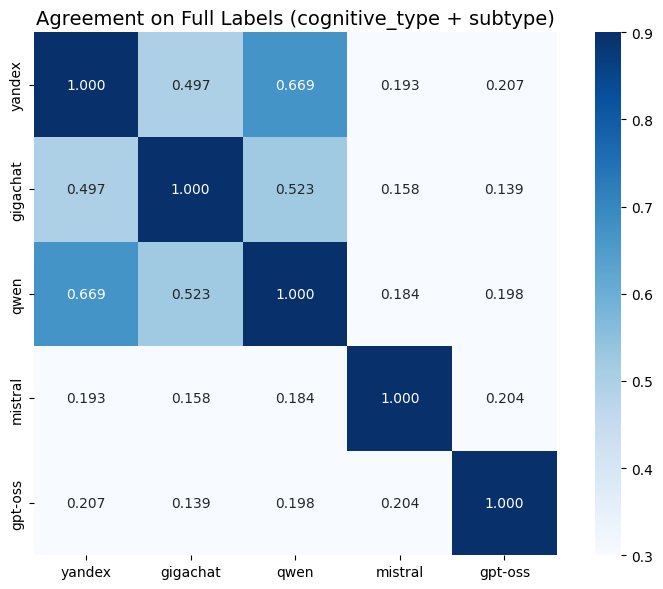


Среднее согласие по полным меткам: 29.7%
Медиана: 20.1%
Мин: 13.9%
Макс: 66.9%

Сравнение с agreement по cognitive_type:
  Cognitive type agreement: 70.9%
  Full label agreement: 29.7%
  Разница: 41.2%


In [31]:
print("="*60)
print("📊 AGREEMENT ПО ВСЕМ МЕТКАМ (cognitive_type + subtype)")
print("="*60)

# Создаем комбинированную метку для каждой модели
combined_dicts = {}
for name, df in models.items():
    # Создаем колонку с комбинированной меткой
    df_temp = df.copy()
    df_temp['full_label'] = df_temp['cognitive_type'] + '::' + df_temp['subtype']
    combined_dicts[name] = dict(zip(df_temp['image_id'], df_temp['full_label']))

# Общие image_id для всех моделей
common_ids = None
for name, df in models.items():
    ids = set(df['image_id'].unique())
    if common_ids is None:
        common_ids = ids
    else:
        common_ids = common_ids & ids

common_ids = sorted(list(common_ids))
print(f"Общих image_id для всех моделей: {len(common_ids)}")

# Матрица Agreement
agreement_full_matrix = pd.DataFrame(index=models.keys(), columns=models.keys(), dtype=float)

for name1, name2 in combinations(models.keys(), 2):
    list1 = [combined_dicts[name1][img_id] for img_id in common_ids]
    list2 = [combined_dicts[name2][img_id] for img_id in common_ids]

    matches = sum(1 for a, b in zip(list1, list2) if a == b)
    agreement = matches / len(common_ids)

    agreement_full_matrix.loc[name1, name2] = agreement
    agreement_full_matrix.loc[name2, name1] = agreement
    print(f"{name1} vs {name2}: {agreement:.2%} ({matches}/{len(common_ids)})")

for name in models.keys():
    agreement_full_matrix.loc[name, name] = 1.0

print("\nМАТРИЦА AGREEMENT (полные метки):")
print(agreement_full_matrix.round(3))

# Визуализация
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(agreement_full_matrix, annot=True, fmt='.3f', cmap='Blues',
            vmin=0.3, vmax=0.9, square=True, ax=ax)
ax.set_title("Agreement on Full Labels (cognitive_type + subtype)", fontsize=14)
plt.tight_layout()
plt.savefig('agreement_full_labels.pdf')
plt.show()

# Статистика
values = agreement_full_matrix.values[np.triu_indices_from(agreement_full_matrix.values, k=1)]
print(f"\n{'='*60}")
print(f"Среднее согласие по полным меткам: {values.mean():.1%}")
print(f"Медиана: {np.median(values):.1%}")
print(f"Мин: {values.min():.1%}")
print(f"Макс: {values.max():.1%}")

# Сравнение с agreement по cognitive_type
print(f"\nСравнение с agreement по cognitive_type:")
print(f"  Cognitive type agreement: {agreement_matrix.values[np.triu_indices(5, k=1)].mean():.1%}")
print(f"  Full label agreement: {values.mean():.1%}")
print(f"  Разница: {(agreement_matrix.values[np.triu_indices(5, k=1)].mean() - values.mean()):.1%}")